# 🚁 NOTEBOOK 01: RAW DATA PARSING & ETL
**Project:** Intelligent Drone Flight Maneuver Recognition  
**Phase:** Data Preprocessing  
**Role:** Embedded ML Engineer

## 🎯 Mục tiêu
1. **Extract:** Giải nén các file `.zip` từ Sensor Logger (được thu ở tần số **100Hz**).
2. **Sync:** Đồng bộ hóa dữ liệu Accelerometer và Gyroscope theo thời gian thực.
3. **Strict Labeling:** Gán nhãn dựa trên **Tên File** (Filename-based Labeling).
4. **Clean Cut:** Cắt bỏ toàn bộ dữ liệu thừa, chỉ giữ lại đoạn **Nhấn Giữ Nút** (Press Duration).
5. **Export:** Xuất ra file `.parquet` (hoặc `.csv`) sạch, sẵn sàng cho việc cắt cửa sổ (Windowing).

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import shutil
from pathlib import Path
import glob

# Mount Google Drive
drive.mount('/content/drive')

# Cấu hình hiển thị
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

Mounted at /content/drive


In [ ]:
# --- CẤU HÌNH HỆ THỐNG ---
BASE_DIR = Path('/content/drive/MyDrive/Drone_Project_2025')

# Input Folders (Bạn cần tạo đúng cấu trúc này trên Drive)
RAW_TRAIN_DIR = BASE_DIR / 'data/raw/train'
RAW_VAL_DIR   = BASE_DIR / 'data/raw/val'

# Output Folder
INTERIM_DATA_DIR = BASE_DIR / 'data/interim'
os.makedirs(INTERIM_DATA_DIR, exist_ok=True)

# Temp Folder để giải nén
TEMP_EXTRACT_DIR = Path('/content/temp_extract')

# --- CẤU HÌNH CẢM BIẾN ---
SAMPLING_RATE = 100  # Hz (Cập nhật mới)
GAP_THRESHOLD = 0.5  # Giây (Khoảng cách giữa các lần nhấn để gộp block - nếu cần)

## 🛠️ CORE FUNCTIONS: ETL LOGIC

In [ ]:
# =============================================================================
# CẬP NHẬT (DEBUG MODE): IN RA THỨ TỰ HÀNH ĐỘNG ĐỂ KIỂM TRA
# =============================================================================

def load_and_sync_session(extract_path, session_label=None, is_validation_seq=False):
    files = {
        'acc': extract_path / 'Accelerometer.csv',
        'gyro': extract_path / 'Gyroscope.csv',
        'anno': extract_path / 'Annotation.csv'
    }
    if not all(f.exists() for f in files.values()): return None

    # 1. Load Sensors
    df_acc = pd.read_csv(files['acc'])
    df_acc['time'] = pd.to_datetime(df_acc['time'], unit='ns')
    df_acc = df_acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
    df_acc = df_acc[['time', 'acc_x', 'acc_y', 'acc_z']].sort_values('time')

    df_gyro = pd.read_csv(files['gyro'])
    df_gyro['time'] = pd.to_datetime(df_gyro['time'], unit='ns')
    df_gyro = df_gyro.rename(columns={'x': 'gyro_x', 'y': 'gyro_y', 'z': 'gyro_z'})
    df_gyro = df_gyro[['time', 'gyro_x', 'gyro_y', 'gyro_z']].sort_values('time')

    df_merged = pd.merge_asof(df_acc, df_gyro, on='time', direction='nearest', tolerance=pd.Timedelta('20ms'))
    df_merged = df_merged.dropna()

    # 2. Xử lý Annotation
    df_anno = pd.read_csv(files['anno'])
    df_anno['end_time'] = pd.to_datetime(df_anno['time'], unit='ns')
    df_anno['start_time'] = df_anno['end_time'] - pd.to_timedelta(df_anno['millisecond_press_duration'], unit='ms')
    df_anno = df_anno.sort_values('start_time')

    # 🔥 LOGIC MAPPING & DEBUG PRINTS 🔥
    if is_validation_seq:
        print("\n🔎 [DEBUG VALIDATION] Tìm thấy các nút bấm sau:")
        maneuver_order = ['MOVE_LEFT', 'MOVE_RIGHT', 'MOVE_FORWARD', 'MOVE_BACKWARD']
        maneuver_counter = 0
        new_labels = []

        for idx, row in df_anno.iterrows():
            lbl = row['text']
            duration = row['millisecond_press_duration'] / 1000.0

            # Logic map
            final_lbl = lbl
            if lbl == 'Maneuver':
                if maneuver_counter < len(maneuver_order):
                    final_lbl = maneuver_order[maneuver_counter]
                    maneuver_counter += 1
                else:
                    final_lbl = 'UNKNOWN_MANEUVER'

            # Sửa lỗi turbulence nếu người dùng lỡ tay bấm Maneuver thay vì Turbulence
            # (Logic phụ: Nếu là bước 5 mà bấm Maneuver thì có thể là Turbulence?) -> Tạm thời giữ nguyên logic nút bấm chuẩn.

            print(f"   - Bấm '{lbl}' ({duration:.1f}s) --> Map thành: {final_lbl}")
            new_labels.append(final_lbl)

        df_anno['text'] = new_labels

    # 3. Cutting
    final_segments = []
    for _, row in df_anno.iterrows():
        start_t = row['start_time']
        end_t   = row['end_time']
        label = session_label if session_label else row['text']

        mask = (df_merged['time'] >= start_t) & (df_merged['time'] <= end_t)
        segment = df_merged.loc[mask].copy()

        if not segment.empty:
            segment['label'] = str(label).upper().strip()
            segment['segment_id'] = _
            final_segments.append(segment)

    if final_segments: return pd.concat(final_segments, ignore_index=True)
    else: return None

In [ ]:

# =============================================================================
# CẬP NHẬT HÀM DUYỆT FOLDER
# =============================================================================
def process_dataset_folder(folder_path, dataset_type='train'):
    all_data = []
    zip_files = list(Path(folder_path).glob('*.zip'))
    print(f"🚀 Đang xử lý bộ {dataset_type.upper()}: {len(zip_files)} files.")

    for zip_path in zip_files:
        file_name_lower = zip_path.name.lower()

        # Logic gán nhãn Train (như cũ)
        forced_label = None
        is_val_seq = False # Cờ đánh dấu file kịch bản validation

        if 'idle' in file_name_lower: forced_label = 'IDLE'
        elif 'hover' in file_name_lower: forced_label = 'HOVER'
        elif 'takeoff' in file_name_lower: forced_label = 'TAKEOFF'
        elif 'landing' in file_name_lower: forced_label = 'LANDING'
        elif 'move_left' in file_name_lower: forced_label = 'MOVE_LEFT'
        elif 'move_right' in file_name_lower: forced_label = 'MOVE_RIGHT'
        elif 'move_forward' in file_name_lower: forced_label = 'MOVE_FORWARD'
        elif 'move_backward' in file_name_lower: forced_label = 'MOVE_BACKWARD'
        elif 'turbulence' in file_name_lower: forced_label = 'TURBULENCE'

        # 🔥 BẮT FILE VALIDATION ĐỂ BẬT CHẾ ĐỘ MAP NHÃN 🔥
        elif 'basic_flight' in file_name_lower:
            forced_label = None
            is_val_seq = True
            print("   -> ⚠️ Phát hiện file kịch bản Validation: Sẽ map nhãn theo thứ tự!")

        # Giải nén & Xử lý
        if TEMP_EXTRACT_DIR.exists(): shutil.rmtree(TEMP_EXTRACT_DIR)
        TEMP_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(TEMP_EXTRACT_DIR)

        # Truyền cờ is_validation_seq vào hàm load
        df_clean = load_and_sync_session(TEMP_EXTRACT_DIR, session_label=forced_label, is_validation_seq=is_val_seq)

        if df_clean is not None:
            all_data.append(df_clean)

    if all_data:
        full_df = pd.concat(all_data, ignore_index=True)
        print(f"✅ Hoàn tất {dataset_type}! Tổng mẫu: {len(full_df)}")
        return full_df
    else:
        return None

## 🏃 EXECUTE PIPELINE

In [ ]:
# 1. Xử lý tập TRAIN
df_train = process_dataset_folder(RAW_TRAIN_DIR, dataset_type='train')

# 2. Xử lý tập VALIDATION (nếu có)
df_val = process_dataset_folder(RAW_VAL_DIR, dataset_type='val')

🚀 Đang xử lý bộ TRAIN: 9 files.
✅ Hoàn tất train! Tổng mẫu: 52362
🚀 Đang xử lý bộ VAL: 1 files.
   -> ⚠️ Phát hiện file kịch bản Validation: Sẽ map nhãn theo thứ tự!

🔎 [DEBUG VALIDATION] Tìm thấy các nút bấm sau:
   - Bấm 'Idle' (4.7s) --> Map thành: Idle
   - Bấm 'Takeoff' (1.6s) --> Map thành: Takeoff
   - Bấm 'Hover' (6.4s) --> Map thành: Hover
   - Bấm 'Maneuver' (2.6s) --> Map thành: MOVE_LEFT
   - Bấm 'Maneuver' (2.6s) --> Map thành: MOVE_RIGHT
   - Bấm 'Maneuver' (2.6s) --> Map thành: MOVE_FORWARD
   - Bấm 'Maneuver' (3.0s) --> Map thành: MOVE_BACKWARD
   - Bấm 'Turbulence' (5.9s) --> Map thành: Turbulence
   - Bấm 'Landing' (2.6s) --> Map thành: Landing
   - Bấm 'Idle' (3.1s) --> Map thành: Idle
✅ Hoàn tất val! Tổng mẫu: 3508


## 📊 DATA QUALITY CHECK (VISUALIZATION)
Kiểm tra xem dữ liệu đã được cắt đúng đoạn "Nhấn nút" chưa.  
Nếu đúng, các đường tín hiệu sẽ trông rất gọn gàng và đặc trưng (Ví dụ: Takeoff là 1 đường Acc_Z vọt lên rồi tắt).

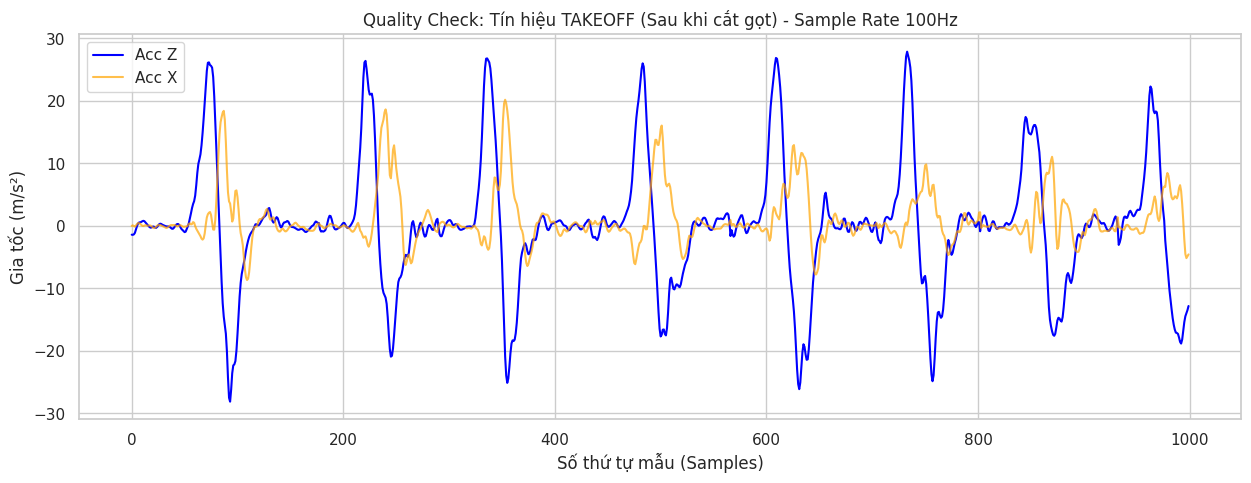


--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN ---
label
MOVE_LEFT        7101
MOVE_BACKWARD    6758
MOVE_FORWARD     6592
HOVER            6359
TURBULENCE       6292
IDLE             6006
MOVE_RIGHT       5453
TAKEOFF          4034
LANDING          3767
Name: count, dtype: int64


In [ ]:
if df_train is not None:
    # Lấy thử 1 label động (ví dụ TAKEOFF hoặc MOVE_LEFT) để soi
    sample_label = 'TAKEOFF' if 'TAKEOFF' in df_train['label'].unique() else df_train['label'].unique()[0]

    subset = df_train[df_train['label'] == sample_label].reset_index(drop=True)

    plt.figure(figsize=(15, 5))
    plt.title(f"Quality Check: Tín hiệu {sample_label} (Sau khi cắt gọt) - Sample Rate 100Hz")

    # Vẽ 1000 mẫu đầu tiên để xem hình dạng
    limit = min(1000, len(subset))
    plt.plot(subset.index[:limit], subset['acc_z'][:limit], label='Acc Z', color='blue')
    plt.plot(subset.index[:limit], subset['acc_x'][:limit], label='Acc X', color='orange', alpha=0.7)

    plt.ylabel("Gia tốc (m/s²)")
    plt.xlabel("Số thứ tự mẫu (Samples)")
    plt.legend()
    plt.show()

    # Kiểm tra phân bố nhãn
    print("\n--- PHÂN BỐ DỮ LIỆU HUẤN LUYỆN ---")
    print(df_train['label'].value_counts())

## 💾 EXPORT INTERIM DATA
Lưu dữ liệu sạch ra CSV để dùng cho Notebook kế tiếp (Windowing & Feature Extraction).

In [ ]:
if df_train is not None:
    save_path = INTERIM_DATA_DIR / 'train_raw_clean.csv'
    df_train.to_csv(save_path, index=False)
    print(f"✅ Đã lưu Train Data: {save_path}")

if df_val is not None:
    save_path = INTERIM_DATA_DIR / 'val_raw_clean.csv'
    df_val.to_csv(save_path, index=False)
    print(f"✅ Đã lưu Val Data: {save_path}")

✅ Đã lưu Train Data: /content/drive/MyDrive/Drone_Project_2025/data/interim/train_raw_clean.csv
✅ Đã lưu Val Data: /content/drive/MyDrive/Drone_Project_2025/data/interim/val_raw_clean.csv
